In [4]:
## SIDEWALKS

In [1]:
import folium
import geopandas as gpd
# Convert to WGS84 (lat/lon) if needed
if eptracts.crs != "EPSG:4326":
    eptracts = eptracts.to_crs(epsg=4326)

# Create a map centered on the data
center = [eptracts.geometry.centroid.y.mean(), eptracts.geometry.centroid.x.mean()]
m = folium.Map(location=center, zoom_start=12)

# Add GeoJSON layer
folium.GeoJson(
    eptracts,
    name="Neighborhoods",
    tooltip=folium.GeoJsonTooltip(
        fields=['Name'],          # replace with a column you want to show on hover
        aliases=['Neighborhood:']
    )
).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Display the map
m


NameError: name 'eptracts' is not defined

In [3]:
import geopandas as gpd

url = (
    "https://arcgis.dvrpc.org/portal/rest/services/transportation/pedestriannetwork_lines/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson"
)

ped = gpd.read_file(url)


In [5]:
#THIS WILL BE USED AT THE END
#I WANT TO CALCULATE INDEX FOR WHOLE CITY FIRST
import geopandas as gpd
tracts = gpd.read_file("philly_neighborhoods.geojson")
# Ensure CRS matches
tracts = tracts.to_crs("EPSG:3857")   
eptracts = tracts[tracts["Name"].str.contains("PASSYUNK_SQUARE", case=False, na=False)]



In [6]:
import pandas as pd
pd.set_option('display.float_format', '{:,.2f}'.format)
tracts = tracts.to_crs("EPSG:32618")   
tracts['area_m2'] = tracts.geometry.area
tracts

,Name,geometry,area_m2
0,LAWNDALE,"POLYGON ((492650.696 4433325.065, 492414.12 44...","3,537,467.57"
1,ASTON_WOODBRIDGE,"POLYGON ((499266.779 4433715.944, 499265.975 4...","1,321,478.09"
2,CARROLL_PARK,"POLYGON ((480639.751 4425251.523, 481194.846 4...","1,217,644.48"
3,CHESTNUT_HILL,"POLYGON ((481860.144 4437364.762, 481864.814 4...","7,396,101.84"
4,BURNHOLME,"POLYGON ((492523.34 4435376.009, 492531.278 44...","978,620.44"
...,...,...,...
153,DICKINSON_NARROWS,"POLYGON ((486974.299 4419683.824, 486930.502 4...","453,072.28"
154,GARDEN_COURT,"POLYGON ((481707.565 4422575.867, 481660.947 4...","295,741.10"
155,WISSAHICKON_HILLS,"POLYGON ((481222.501 4431949.862, 481176.751 4...","282,463.83"
156,DEARNLEY_PARK,"POLYGON ((478557.527 4432621.566, 478665.632 4...","1,502,227.41"


In [7]:
total_area_m2 = tracts['area_m2'].sum()
print(f"Total area: {total_area_m2:,.2f} m²")


Total area: 369,285,108.40 m²


In [ ]:
##CURBS

In [8]:
import geopandas as gpd

curbs = gpd.read_file("Curbs.geojson"
).to_crs(epsg=3857)
nocurbs = gpd.read_file("Curbs_No_Cartways.geojson"
).to_crs(epsg=3857)
curbs

,objectid,curbs_poly_,curbs_poly_id,fcode,elev_1,elev_2,elev_3,update_,add_date,chg_src,cp_id,Shape__Area,Shape__Length,geometry
0,1,None,None,9999,"1,000.00",NaN,NaN,2013-01-25 00:00:00+00:00,None,None,26252,411.69,83.46,"POLYGON ((-8379905.294 4846175.211, -8379906.4..."
1,2,None,None,1012,NaN,NaN,NaN,2013-01-25 00:00:00+00:00,None,None,26253,42.54,52.15,"POLYGON ((-8379888.089 4846212.303, -8379888.3..."
2,3,None,None,1012,NaN,NaN,NaN,2013-01-25 00:00:00+00:00,None,None,26254,267.73,408.36,"POLYGON ((-8379662.13 4846252.296, -8379662.53..."
3,4,None,None,1032,NaN,NaN,NaN,2013-01-28 00:00:00+00:00,None,None,26256,709.10,234.47,"POLYGON ((-8378128.326 4847661.877, -8378127.0..."
4,5,None,None,1032,NaN,NaN,NaN,2013-01-28 00:00:00+00:00,None,None,26258,364.43,99.66,"POLYGON ((-8378573.014 4847747.805, -8378573.7..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24587,24588,None,None,9999,0.00,0.00,0.00,NaT,None,None,5,"49,798.20","1,135.25","POLYGON ((-8350234.852 4885678.21, -8350232.62..."
24588,24589,None,None,9999,0.00,0.00,0.00,NaT,None,None,4,"45,909.00","1,002.20","POLYGON ((-8350341.021 4885755.183, -8350337.2..."
24589,24590,None,None,1032,0.00,0.00,0.00,NaT,None,None,3,31.89,24.20,"POLYGON ((-8350337.064 4885762.844, -8350336.4..."
24590,24591,None,None,9999,0.00,0.00,0.00,NaT,None,None,2,"28,823.90",742.02,"POLYGON ((-8350501.983 4885892.195, -8350499.9..."


In [ ]:
nocurbs

,OBJECTID,CURBS_POLY,CURBS_PO_1,FCODE,ELEV_1,ELEV_2,ELEV_3,UPDATE_,ADD_DATE,CHG_SRC,CP_ID,Shape__Area,Shape__Length,geometry
0,1,None,None,9999,1000,0,0,2013-01-25 00:00:00+00:00,None,None,26252,411.69,83.46,"POLYGON ((-8379905.294 4846175.211, -8379906.4..."
1,2,None,None,9999,0,0,0,2013-07-02 00:00:00+00:00,None,None,26362,"281,125.53","2,333.26","POLYGON ((-8378080.382 4847808.052, -8378078.1..."
2,3,None,None,9999,1020,0,0,2006-03-23 00:00:00+00:00,None,None,25597,"3,250.10","1,467.02","POLYGON ((-8377454.185 4847774.03, -8377442.19..."
3,4,None,None,9999,1020,0,0,2006-03-23 00:00:00+00:00,None,None,25599,"84,010.97","14,606.51","POLYGON ((-8378104.337 4847923.462, -8378105.0..."
4,5,None,None,9999,1020,0,0,2006-03-28 00:00:00+00:00,None,None,24228,21.09,20.14,"POLYGON ((-8378098.918 4847929.831, -8378101.1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17350,17351,None,None,9999,0,0,0,NaT,None,None,8,"35,534.50",847.38,"POLYGON ((-8350632.007 4885552.579, -8350631.7..."
17351,17352,None,None,9999,0,0,0,NaT,None,None,7,"25,745.82",652.08,"POLYGON ((-8350412.864 4885610.395, -8350408.0..."
17352,17353,None,None,9999,0,0,0,NaT,None,None,6,"44,781.14",835.40,"POLYGON ((-8350140.275 4885603.045, -8350138.9..."
17353,17354,None,None,9999,0,0,0,NaT,None,None,5,"49,798.19","1,135.25","POLYGON ((-8350234.853 4885678.21, -8350232.62..."


In [ ]:
curbs['cartway'] = 1
nocurbs['cartway'] = 0
curbs

,objectid,curbs_poly_,curbs_poly_id,fcode,elev_1,elev_2,elev_3,update_,add_date,chg_src,cp_id,Shape__Area,Shape__Length,geometry,cartway
0,1,None,None,9999,"1,000.00",NaN,NaN,2013-01-25 00:00:00+00:00,None,None,26252,411.69,83.46,"POLYGON ((-8379905.294 4846175.211, -8379906.4...",1
1,2,None,None,1012,NaN,NaN,NaN,2013-01-25 00:00:00+00:00,None,None,26253,42.54,52.15,"POLYGON ((-8379888.089 4846212.303, -8379888.3...",1
2,3,None,None,1012,NaN,NaN,NaN,2013-01-25 00:00:00+00:00,None,None,26254,267.73,408.36,"POLYGON ((-8379662.13 4846252.296, -8379662.53...",1
3,4,None,None,1032,NaN,NaN,NaN,2013-01-28 00:00:00+00:00,None,None,26256,709.10,234.47,"POLYGON ((-8378128.326 4847661.877, -8378127.0...",1
4,5,None,None,1032,NaN,NaN,NaN,2013-01-28 00:00:00+00:00,None,None,26258,364.43,99.66,"POLYGON ((-8378573.014 4847747.805, -8378573.7...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24587,24588,None,None,9999,0.00,0.00,0.00,NaT,None,None,5,"49,798.20","1,135.25","POLYGON ((-8350234.852 4885678.21, -8350232.62...",1
24588,24589,None,None,9999,0.00,0.00,0.00,NaT,None,None,4,"45,909.00","1,002.20","POLYGON ((-8350341.021 4885755.183, -8350337.2...",1
24589,24590,None,None,1032,0.00,0.00,0.00,NaT,None,None,3,31.89,24.20,"POLYGON ((-8350337.064 4885762.844, -8350336.4...",1
24590,24591,None,None,9999,0.00,0.00,0.00,NaT,None,None,2,"28,823.90",742.02,"POLYGON ((-8350501.983 4885892.195, -8350499.9...",1


In [ ]:
import geopandas as gpd

combined = gpd.GeoDataFrame(
    pd.concat([curbs, nocurbs], ignore_index=True),
    crs=curbs.crs
)
combined.geometry

0        POLYGON ((-8379905.294 4846175.211, -8379906.4...
1        POLYGON ((-8379888.089 4846212.303, -8379888.3...
2        POLYGON ((-8379662.13 4846252.296, -8379662.53...
3        POLYGON ((-8378128.326 4847661.877, -8378127.0...
4        POLYGON ((-8378573.014 4847747.805, -8378573.7...
                               ...                        
41942    POLYGON ((-8350632.007 4885552.579, -8350631.7...
41943    POLYGON ((-8350412.864 4885610.395, -8350408.0...
41944    POLYGON ((-8350140.275 4885603.045, -8350138.9...
41945    POLYGON ((-8350234.853 4885678.21, -8350232.62...
41946    POLYGON ((-8350341.021 4885755.183, -8350337.2...
Name: geometry, Length: 41947, dtype: geometry

C:\Users\kalmanj\AppData\Local\Temp\ipykernel_17932\3306804503.py:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\kalmanj\AppData\Local\Temp\ipykernel_17932\3306804503.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


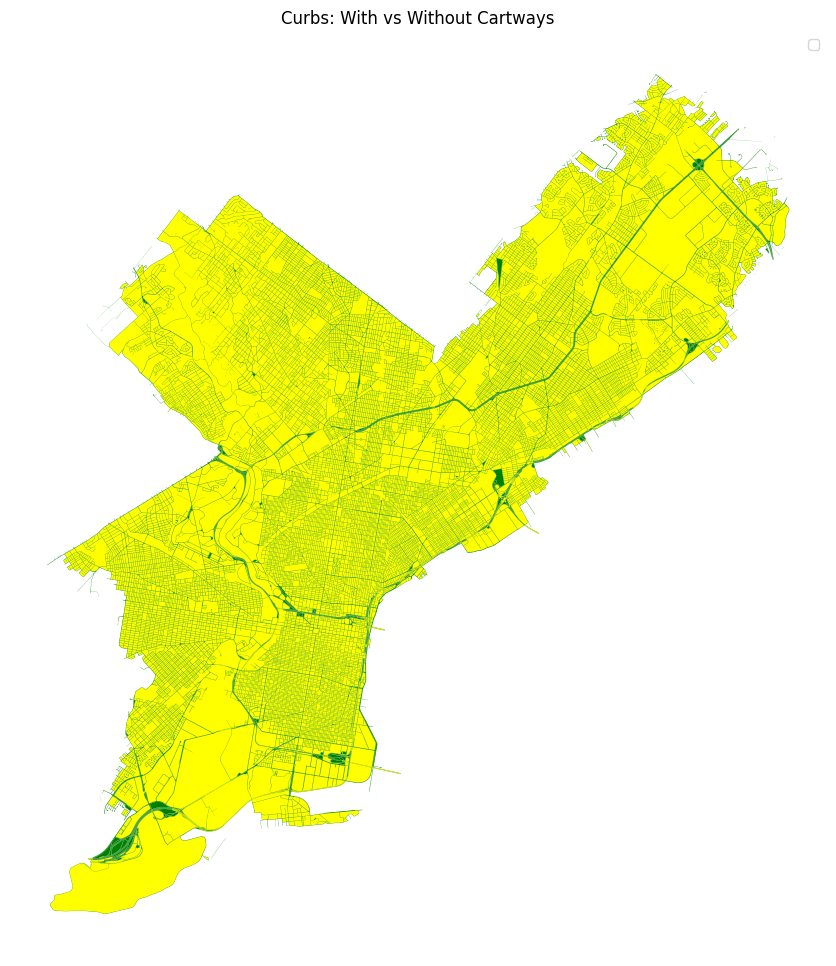

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

combined[combined["cartway"] == 1].plot(
    ax=ax, color="green", linewidth=0.7, label="With Cartway"
)

combined[combined["cartway"] == 0].plot(
    ax=ax, color="yellow", linewidth=0.7, label="Without Cartway"
)

ax.set_title("Curbs: With vs Without Cartways")
ax.legend()
ax.axis("off")
plt.show()


In [ ]:
tracts = tracts.to_crs(3857)

curbs_joined = gpd.sjoin(combined, tracts[["Name", "geometry"]], 
                         how="right", 
                         predicate="intersects")
curbs_joined.Shape__Area

0       3,601.96
0         127.16
0       1,530.76
0         548.06
0       1,474.75
         ...    
157    24,011.90
157   399,469.46
157    86,700.95
157    33,913.66
157    59,720.09
Name: Shape__Area, Length: 44286, dtype: float64

In [ ]:
total_area = (
    curbs_joined.groupby("Name")["Shape__Area"]
    .sum()
    .reset_index(name="total_curb_area")
)


In [ ]:
cartway_area = (
    curbs_joined[curbs_joined["cartway"] == 1]
    .groupby("Name")["Shape__Area"]
    .sum()
    .reset_index(name="cartway_area")
)


In [ ]:
curbsummary = tracts[["Name", "geometry"]].merge(total_area, on="Name", how="left")
curbsummary = summary.merge(cartway_area, on="Name", how="left")
curbsummary

,Name,geometry,total_curb_area,cartway_area_x,cartway_area_y
0,LAWNDALE,"POLYGON ((-8358553.218 4873230.139, -8358861.1...","32,898,698.54","27,095,888.25","27,095,888.25"
1,ASTON_WOODBRIDGE,"POLYGON ((-8349918.77 4873746.906, -8349919.81...","30,649,804.84","25,959,130.58","25,959,130.58"
2,CARROLL_PARK,"POLYGON ((-8374201.54 4862629.945, -8373476.79...","14,754,256.79","12,878,404.75","12,878,404.75"
3,CHESTNUT_HILL,"POLYGON ((-8372648.259 4878500.7, -8372642.137...","59,068,870.39","43,136,848.45","43,136,848.45"
4,BURNHOLME,"POLYGON ((-8358722.064 4875917.543, -8358711.6...","24,440,279.79","22,849,155.71","22,849,155.71"
...,...,...,...,...,...
153,DICKINSON_NARROWS,"POLYGON ((-8365930.897 4855362.957, -8365987.3...","7,300,951.34","6,647,949.09","6,647,949.09"
154,GARDEN_COURT,"POLYGON ((-8372801.078 4859132.007, -8372860.9...","11,842,045.39","11,421,707.32","11,421,707.32"
155,WISSAHICKON_HILLS,"POLYGON ((-8373463.387 4871402.731, -8373522.9...","30,411,549.68","28,788,932.64","28,788,932.64"
156,DEARNLEY_PARK,"POLYGON ((-8376943.188 4872273.448, -8376802.5...","33,203,078.59","30,183,775.00","30,183,775.00"


In [ ]:
curbsummary["cartway_density"] = curbsummary["cartway_area_x"] / curbsummary["total_curb_area"]
curbsummary.loc[curbsummary["total_curb_area"] == 0, "cartway_density"] = 0


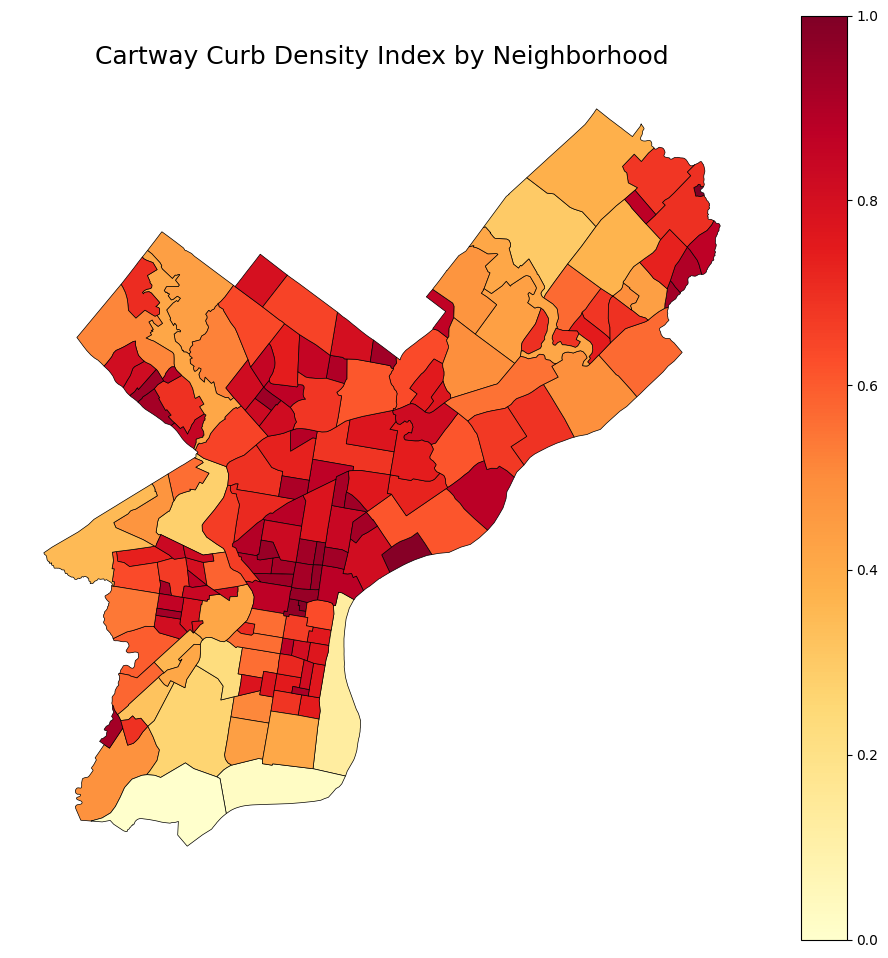

In [ ]:
min_val = curbsummary["cartway_density"].replace(0, pd.NA).min()
max_val = curbsummary["cartway_density"].max()

curbsummary["cartway_density_index"] = (
    (curbsummary["cartway_density"] - min_val) /
    (max_val - min_val)
)

curbsummary["cartway_density_index"] = curbsummary["cartway_density_index"].fillna(0)

# -----------------------------
# 11. Plot it
# -----------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
curbsummary.plot(
    column="cartway_density_index",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title("Cartway Curb Density Index by Neighborhood", fontsize=18)
ax.axis("off")
plt.show()


In [ ]:
curbsummary[curbsummary['Name'].str.contains('PASSYUNK', case=False, na=False)]


,Name,geometry,total_curb_area,cartway_area_x,cartway_area_y,cartway_density,cartway_density_index
105,WEST_PASSYUNK,"POLYGON ((-8369586.644 4855803.708, -8368479.0...","7,651,816.20","6,824,419.24","6,824,419.24",0.89,0.78
107,EAST_PASSYUNK,"POLYGON ((-8367853.929 4854965.745, -8367702.9...","7,874,374.53","6,934,835.26","6,934,835.26",0.88,0.75
152,PASSYUNK_SQUARE,"POLYGON ((-8366389.14 4855805.09, -8366417.305...","8,240,395.09","7,117,671.11","7,117,671.11",0.86,0.72


In [ ]:
# BIKING ACCESS

In [ ]:
biking=gpd.read_file('Bike_Network.geojson')
biking

,OBJECTID,SEG_ID,STREETNAME,ST_CODE,ONEWAY,CLASS,TYPE,Shape__Length,geometry
0,1,100002,BARTRAM AVE,16120,B,2,Paint Buffered,"1,137.34","LINESTRING (-75.25362 39.88134, -75.25383 39.8..."
1,2,100003,BARTRAM AVE,16120,B,2,Paint Buffered,371.89,"LINESTRING (-75.25149 39.88373, -75.25337 39.8..."
2,3,100004,BARTRAM AVE,16120,B,2,Paint Buffered,48.72,"LINESTRING (-75.25337 39.88161, -75.25362 39.8..."
3,4,100021,LINDBERGH BLVD,50820,B,5,Separated Bike Lane,467.54,"LINESTRING (-75.25245 39.89751, -75.25429 39.8..."
4,5,100040,ISLAND AVE,45120,FT,2,Paint Buffered,191.42,"LINESTRING (-75.23749 39.89575, -75.23699 39.8..."
...,...,...,...,...,...,...,...,...,...
5220,5221,1180031,SOUTHAMPTON RD,73480,B,3,Conventional,178.37,"LINESTRING (-75.00167 40.124, -75.00038 40.12327)"
5221,5222,1180041,SOUTHAMPTON RD,73480,B,3,Conventional,204.64,"LINESTRING (-75.00038 40.12327, -74.99892 40.1..."
5222,5223,1180048,SOUTHAMPTON RD,73480,B,3,Conventional,79.84,"LINESTRING (-74.99892 40.12243, -74.99838 40.1..."
5223,5224,1180058,SOUTHAMPTON RD,73480,B,3,Conventional,184.19,"LINESTRING (-74.99647 40.12079, -74.99526 40.1..."


In [ ]:
tracts = tracts.to_crs(4326)

biking_join= gpd.sjoin(biking, tracts[["Name", "geometry"]], 
                         how="right", 
                         predicate="intersects")

biking_join['total_area']= tracts['area_m2']
biking_join

,index_left,OBJECTID,SEG_ID,STREETNAME,ST_CODE,ONEWAY,CLASS,TYPE,Shape__Length,Name,geometry,total_area
0,"4,022.00","4,023.00","740,014.00",TABOR AVE,"76,025.00",B,3.00,Sharrow,224.74,LAWNDALE,"POLYGON ((-75.08616 40.05013, -75.08893 40.044...","3,537,467.57"
0,"4,057.00","4,058.00","740,196.00",RISING SUN AVE,"68,600.00",B,3.00,Conventional,224.27,LAWNDALE,"POLYGON ((-75.08616 40.05013, -75.08893 40.044...","3,537,467.57"
0,"4,059.00","4,060.00","740,235.00",RISING SUN AVE,"68,600.00",B,3.00,Conventional,118.17,LAWNDALE,"POLYGON ((-75.08616 40.05013, -75.08893 40.044...","3,537,467.57"
0,"4,060.00","4,061.00","740,252.00",OXFORD AVE,"62,080.00",B,2.00,Conventional,233.57,LAWNDALE,"POLYGON ((-75.08616 40.05013, -75.08893 40.044...","3,537,467.57"
0,"4,061.00","4,062.00","740,266.00",RISING SUN AVE,"68,600.00",B,3.00,Conventional,106.96,LAWNDALE,"POLYGON ((-75.08616 40.05013, -75.08893 40.044...","3,537,467.57"
...,...,...,...,...,...,...,...,...,...,...,...,...
157,"3,070.00","3,071.00","600,015.00",UMBRIA ST,"78,840.00",B,3.00,Sharrow,99.66,GERMANY_HILL,"POLYGON ((-75.22723 40.03529, -75.231 40.03312...","633,652.68"
157,"3,800.00","3,801.00","700,185.00",RIDGE AVE,"68,280.00",B,2.00,Sharrow,130.91,GERMANY_HILL,"POLYGON ((-75.22723 40.03529, -75.231 40.03312...","633,652.68"
157,"3,818.00","3,819.00","700,367.00",RIDGE AVE,"68,280.00",B,2.00,Sharrow,27.92,GERMANY_HILL,"POLYGON ((-75.22723 40.03529, -75.231 40.03312...","633,652.68"
157,"3,819.00","3,820.00","700,368.00",RIDGE AVE,"68,280.00",B,2.00,Sharrow,90.49,GERMANY_HILL,"POLYGON ((-75.22723 40.03529, -75.231 40.03312...","633,652.68"


In [ ]:
biking_join.TYPE.unique()

array(['Sharrow', 'Conventional', 'Paint Buffered',
       'One Way Separated Bike Lane', 'Two Way Separated Bike Lane',
       'Separated Bike Lane', 'Contraflow', 'Conventional w Sharrows',
       'Paint Buffered w Conventional', nan,
       'Conventional & Dashed Bike Lane', 'Dashed Bike Lane',
       'Bus Bike Lane'], dtype=object)

In [ ]:
total_length = (
    biking_join.groupby("Name")["Shape__Length"]
    .sum()
    .reset_index(name="total_lane_length")
)

bikesummary = tracts[["Name", "geometry", "area_m2"]].merge(total_length, on="Name", how="left")

bikesummary

,Name,geometry,area_m2,total_lane_length
0,LAWNDALE,"POLYGON ((-75.08616 40.05013, -75.08893 40.044...","3,537,467.57","8,827.98"
1,ASTON_WOODBRIDGE,"POLYGON ((-75.0086 40.05369, -75.00861 40.0535...","1,321,478.09","3,305.02"
2,CARROLL_PARK,"POLYGON ((-75.22673 39.9772, -75.22022 39.9742...","1,217,644.48","2,876.21"
3,CHESTNUT_HILL,"POLYGON ((-75.21278 40.08637, -75.21272 40.086...","7,396,101.84","2,075.24"
4,BURNHOLME,"POLYGON ((-75.08768 40.06861, -75.08758 40.068...","978,620.44","1,769.57"
...,...,...,...,...
153,DICKINSON_NARROWS,"POLYGON ((-75.15244 39.92716, -75.15294 39.924...","453,072.28",542.07
154,GARDEN_COURT,"POLYGON ((-75.21415 39.95312, -75.21469 39.950...","295,741.10","1,338.70"
155,WISSAHICKON_HILLS,"POLYGON ((-75.2201 40.03757, -75.22064 40.0372...","282,463.83","1,526.93"
156,DEARNLEY_PARK,"POLYGON ((-75.25136 40.04355, -75.2501 40.0446...","1,502,227.41","3,836.14"


In [ ]:
bikesummary["bike_lane_density"] = (bikesummary["total_lane_length"] / bikesummary["area_m2"])*10
bikesummary

,Name,geometry,area_m2,total_lane_length,bike_lane_density
0,LAWNDALE,"POLYGON ((-75.08616 40.05013, -75.08893 40.044...","3,537,467.57","8,827.98",0.02
1,ASTON_WOODBRIDGE,"POLYGON ((-75.0086 40.05369, -75.00861 40.0535...","1,321,478.09","3,305.02",0.03
2,CARROLL_PARK,"POLYGON ((-75.22673 39.9772, -75.22022 39.9742...","1,217,644.48","2,876.21",0.02
3,CHESTNUT_HILL,"POLYGON ((-75.21278 40.08637, -75.21272 40.086...","7,396,101.84","2,075.24",0.00
4,BURNHOLME,"POLYGON ((-75.08768 40.06861, -75.08758 40.068...","978,620.44","1,769.57",0.02
...,...,...,...,...,...
153,DICKINSON_NARROWS,"POLYGON ((-75.15244 39.92716, -75.15294 39.924...","453,072.28",542.07,0.01
154,GARDEN_COURT,"POLYGON ((-75.21415 39.95312, -75.21469 39.950...","295,741.10","1,338.70",0.05
155,WISSAHICKON_HILLS,"POLYGON ((-75.2201 40.03757, -75.22064 40.0372...","282,463.83","1,526.93",0.05
156,DEARNLEY_PARK,"POLYGON ((-75.25136 40.04355, -75.2501 40.0446...","1,502,227.41","3,836.14",0.03


In [ ]:
summary.bike_lane_density.max()

0.12395443051303635

In [ ]:
min_density = bikesummary["bike_lane_density"].min()
max_density = bikesummary["bike_lane_density"].max()

bikesummary["bike_index"] = (bikesummary["bike_lane_density"] - min_density) / (max_density - min_density)
bikesummary["bike_index"] = bikesummary["bike_index"].clip(lower=0)  # ensure no negatives

In [ ]:
bikesummary

,Name,geometry,area_m2,total_lane_length,bike_lane_density,bike_index
0,LAWNDALE,"POLYGON ((-75.08616 40.05013, -75.08893 40.044...","3,537,467.57","8,827.98",0.02,0.20
1,ASTON_WOODBRIDGE,"POLYGON ((-75.0086 40.05369, -75.00861 40.0535...","1,321,478.09","3,305.02",0.03,0.20
2,CARROLL_PARK,"POLYGON ((-75.22673 39.9772, -75.22022 39.9742...","1,217,644.48","2,876.21",0.02,0.19
3,CHESTNUT_HILL,"POLYGON ((-75.21278 40.08637, -75.21272 40.086...","7,396,101.84","2,075.24",0.00,0.02
4,BURNHOLME,"POLYGON ((-75.08768 40.06861, -75.08758 40.068...","978,620.44","1,769.57",0.02,0.15
...,...,...,...,...,...,...
153,DICKINSON_NARROWS,"POLYGON ((-75.15244 39.92716, -75.15294 39.924...","453,072.28",542.07,0.01,0.10
154,GARDEN_COURT,"POLYGON ((-75.21415 39.95312, -75.21469 39.950...","295,741.10","1,338.70",0.05,0.37
155,WISSAHICKON_HILLS,"POLYGON ((-75.2201 40.03757, -75.22064 40.0372...","282,463.83","1,526.93",0.05,0.44
156,DEARNLEY_PARK,"POLYGON ((-75.25136 40.04355, -75.2501 40.0446...","1,502,227.41","3,836.14",0.03,0.21


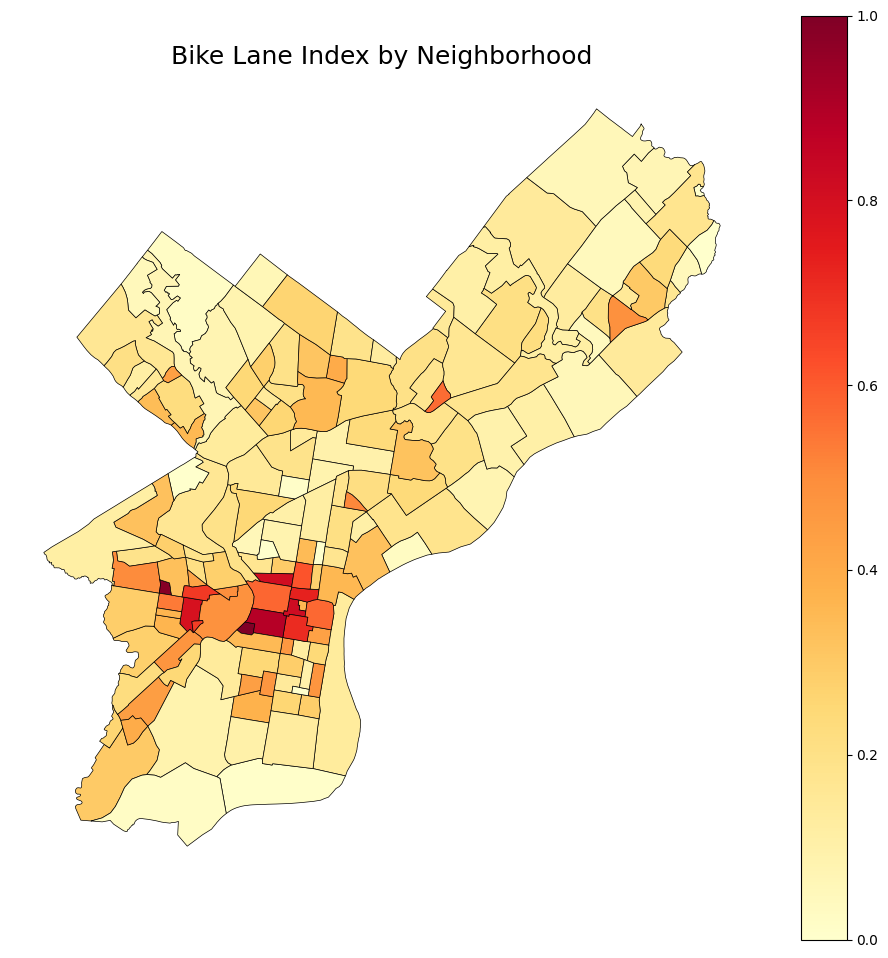

In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
bikesummary.plot(
    column="bike_index",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title("Bike Lane Index by Neighborhood", fontsize=18)
ax.axis("off")
plt.show()


In [ ]:
bikesummary[bikesummary['Name'].str.contains('PASSYUNK', case=False, na=False)]


,Name,geometry,area_m2,total_lane_length,bike_lane_density,bike_index
105,WEST_PASSYUNK,"POLYGON ((-75.18528 39.9302, -75.17533 39.9288...","594,307.32","3,250.53",0.05,0.44
107,EAST_PASSYUNK,"POLYGON ((-75.16971 39.92442, -75.16835 39.930...","611,168.96","1,078.43",0.02,0.14
152,PASSYUNK_SQUARE,"POLYGON ((-75.15655 39.93021, -75.15681 39.929...","810,012.36","2,897.14",0.04,0.29


In [ ]:
import osmnx as ox

In [ ]:
philly = ox.geocode_to_gdf("Philadelphia, PA")

philly.head()

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-75.28027 39.97496, -75.28023 39.974...",-75.28,39.87,-74.96,40.14,331386626,relation,188022,39.95,-75.16,boundary,administrative,16,0.77,city,Philadelphia,"Philadelphia, Philadelphia County, Pennsylvani..."


In [ ]:
# Get all amenities in Philadelphia
amenities = ox.features_from_place("Philadelphia, PA", tags={"amenity": True})

In [ ]:
amenities.amenity.unique()

array(['bench', 'parking_entrance', 'atm', 'cafe', 'car_sharing',
       'restaurant', 'bank', 'cinema', 'pub', 'school',
       'place_of_worship', 'college', 'doctors', 'post_office',
       'social_facility', 'nursing_home', 'hospital', 'bicycle_parking',
       'music_venue', 'fire_station', 'library', 'police',
       'community_centre', 'fraternity', 'fountain', 'studio',
       'veterinary', 'theatre', 'fast_food', 'training', 'drinking_water',
       'post_box', 'pharmacy', 'fuel', 'loading_dock', 'ice_cream', 'bar',
       'toilets', 'taxi', 'dojo', 'parking', 'shelter', 'kindergarten',
       'car_wash', 'vending_machine', 'food_court', 'car_rental',
       'marketplace', 'nightclub', 'childcare', 'events_venue',
       'tool_library', 'prep_school', 'clinic', 'university',
       'animal_boarding', 'bicycle_rental', 'payment_centre',
       'waste_basket', 'bicycle_repair_station', 'recycling',
       'ferry_terminal', 'bureau_de_change', 'animal_training',
       'telephone

In [ ]:
amenities

geometry  \
element id                                                              
way     25430386    LINESTRING (-75.15094 39.93328, -75.15085 39.9...   
        30862223    LINESTRING (-75.20873 39.94547, -75.20868 39.9...   
        30863665    LINESTRING (-75.20861 39.94562, -75.20873 39.9...   
        31372814    LINESTRING (-75.15105 39.95498, -75.15089 39.9...   
        32122415    LINESTRING (-75.17125 39.95864, -75.17129 39.9...   
...                                                               ...   
        1454572249  LINESTRING (-75.24791 39.96277, -75.2476 39.96...   
        1454790320  LINESTRING (-75.22625 40.00121, -75.22623 40.0...   
        1454790321  LINESTRING (-75.22648 40.00113, -75.22648 40.0...   
        1454790322  LINESTRING (-75.22648 40.00113, -75.2265 40.00...   
        1454790323  LINESTRING (-75.22632 40.0014, -75.22628 40.00...   

                     footway  highway bicycle         crossing      dog  \
element id                                                                
way     25430386    sidewalk  footway     NaN              NaN      NaN   
        30862223    crossing  footway     yes           marked  leashed   
        30863665    sidewalk  footway     NaN              NaN  leashed   
        31372814    sidewalk  footway      no              NaN      NaN   
        32122415    crossing  footway     NaN  traffic_signals      NaN   
...                      ...      ...     ...              ...      ...   
        1454572249  sidewalk  footway     NaN              NaN      NaN   
        1454790320  sidewalk  footway     NaN              NaN      NaN   
        1454790321  sidewalk  footway     NaN              NaN      NaN   
        1454790322  crossing  footway     NaN     uncontrolled      NaN   
        1454790323  crossing  footway     NaN     uncontrolled      NaN   

                   dog:leash:maxlength smoothness  \
element id                                          
way     25430386                   NaN        NaN   
        30862223                  6 ft       good   
        30863665                  6 ft       good   
        31372814                   NaN        NaN   
        32122415                   NaN        NaN   
...                                ...        ...   
        1454572249                 NaN        NaN   
        1454790320                 NaN        NaN   
        1454790321                 NaN        NaN   
        1454790322                 NaN        NaN   
        1454790323                 NaN        NaN   

                                                       source:bicycle  \
element id                                                              
way     25430386                                                  NaN   
        30862223    https://www.phila.gov/departments/philadelphia...   
        30863665    https://www.phila.gov/departments/philadelphia...   
        31372814                                                  NaN   
        32122415                                                  NaN   
...                                                               ...   
        1454572249                                                NaN   
        1454790320                                                NaN   
        1454790321                                                NaN   
        1454790322                                                NaN   
        1454790323                                                NaN   

                                                           source:dog  ...  \
element id                                                             ...   
way     25430386                                                  NaN  ...   
        30862223    https://www.phila.gov/departments/philadelphia...  ...   
        30863665    https://www.phila.gov/departments/philadelphia...  ...   
        31372814                                                  NaN  ...   
        32122415           

In [ ]:
tracts = gpd.read_file("philly_neighborhoods.geojson")
# Ensure CRS matches
tracts = tracts.to_crs("EPSG:4269")   
eptracts = tracts[tracts["Name"].str.contains("PASSYUNK_SQUARE", case=False, na=False)]

In [ ]:
eptracts = eptracts.squeeze().geometry
eptracts = eptracts.to_crs("EPSG:4269")   

eptracts, type(eptracts)

AttributeError: 'Polygon' object has no attribute 'to_crs'

In [ ]:
G_cc = ox.graph_from_polygon(eptracts, network_type="drive")

In [ ]:
ox.basic_stats(G_cc)

{'n': 170,
 'm': 299,
 'k_avg': 3.5176470588235293,
 'edge_length_total': 21939.280655621973,
 'edge_length_avg': 73.37552058736446,
 'streets_per_node_avg': 3.3117647058823527,
 'streets_per_node_counts': {0: 0, 1: 12, 2: 0, 3: 81, 4: 77},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.07058823529411765,
  2: 0.0,
  3: 0.4764705882352941,
  4: 0.45294117647058824},
 'intersection_count': 158,
 'street_length_total': 19471.5118029778,
 'street_segment_count': 259,
 'street_length_avg': 75.17958225087953,
 'circuity_avg': 1.0072848584856577,
 'self_loop_proportion': 0.0}

In [ ]:
import geopandas as gpd
import networkx as nx
import pandas as pd

# Ensure CRS matches for accurate distance/area calculations
footways_in_neighborhood = footways_in_neighborhood.to_crs(epsg=3857)
amenities = amenities.to_crs(epsg=3857)
tracts = tracts.to_crs(epsg=3857)

# Assign footways to neighborhoods
footways_in_neighborhood = gpd.sjoin(
    amenities, 
    tracts[['Name', 'geometry']], 
    how='inner', 
    predicate='intersects'
)

# Calculate total sidewalk length per neighborhood
footways_in_neighborhood['length_m'] = footways_in_neighborhood.geometry.length
sidewalk_lengths = footways_in_neighborhood.groupby('Name')['length_m'].sum().reset_index()

# Count total footways per neighborhood
sidewalk_counts = footways_in_neighborhood.groupby('Name').size().reset_index(name='total_sidewalks')

# Initialize a list for sidewalk gap metrics
gap_metrics = []

for name, group in footways_in_neighborhood.groupby('Name'):
    G = nx.Graph()
    
    # Add edges for each footway (linestring) in the neighborhood
    for geom in group.geometry:
        if geom is None:
            continue
        coords = list(geom.coords)
        for start, end in zip(coords[:-1], coords[1:]):
            G.add_edge(start, end)
    
    # Count connected components
    num_components = nx.number_connected_components(G)
    
    # Number of gaps = components - 1
    num_gaps = max(num_components - 1, 0)
    
    # Store results
    gap_metrics.append({
        'Name': name,
        'num_gaps': num_gaps,
    })

gaps_df = pd.DataFrame(gap_metrics)

# Merge counts, lengths, and gaps
sidewalk_summary = sidewalk_counts.merge(sidewalk_lengths, on='Name')
sidewalk_summary = sidewalk_summary.merge(gaps_df, on='Name', how='left')

# Compute gap density (gaps per sidewalk)
sidewalk_summary['gap_density'] = sidewalk_summary['num_gaps'] / sidewalk_summary['total_sidewalks']

# Normalize gap density to 0-1 index
min_val = sidewalk_summary['gap_density'].min()
max_val = sidewalk_summary['gap_density'].max()
sidewalk_summary['sidewalk_index'] = 1 - ((sidewalk_summary['gap_density'] - (min_val+0.01)) / (max_val - min_val))

# Inspect top neighborhoods by index
print(sidewalk_summary.sort_values('sidewalk_index', ascending=True).head(100))


                  Name  total_sidewalks  length_m  num_gaps  gap_density  \
58           GREENWICH               11    306.10         9         0.82   
151             WISTER               19    365.50        11         0.58   
48   GERMANTOWN_MORTON               20  1,381.53        10         0.50   
110      PORT_RICHMOND                6    419.98         2         0.33   
1              AIRPORT               54  4,132.12        15         0.28   
..                 ...              ...       ...       ...          ...   
129             TACONY              262 18,031.17         8         0.03   
132    UNIVERSITY_CITY              998 75,533.71        30         0.03   
128         SUMMERDALE              168  8,304.81         5         0.03   
40       FITLER_SQUARE               68  4,429.85         2         0.03   
43           FRANKFORD              410 25,000.07        12         0.03   

     sidewalk_index                                           geometry  
58            

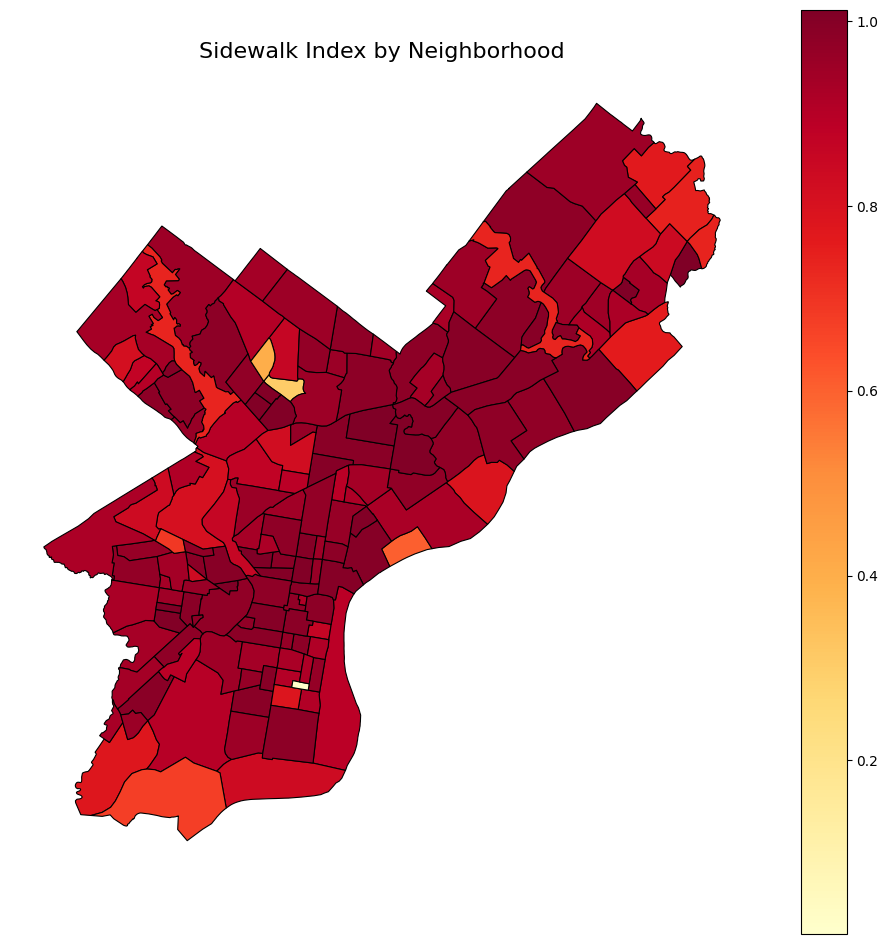

In [ ]:
# Rebuild the GeoDataFrame by merging index back onto tracts
sidewalk_summary = tracts[['Name', 'geometry']].merge(
    sidewalk_summary[['Name', 'sidewalk_index']],
    on='Name',
    how='left'
)

# Convert to GeoDataFrame
sidewalk_summary = gpd.GeoDataFrame(sidewalk_summary, geometry='geometry', crs=tracts.crs)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

sidewalk_summary.plot(
    column='sidewalk_index',
    cmap='YlOrRd',
    edgecolor='black',   # <-- correct spelling!
    linewidth=0.8,
    legend=True,
    ax=ax
)

ax.set_title("Sidewalk Index by Neighborhood", fontsize=16)
ax.axis('off')
plt.show()


In [ ]:
sidewalk_summary[sidewalk_summary['Name'].str.contains('PASSYUNK', case=False, na=False)]


,Name,geometry,sidewalk_index
105,WEST_PASSYUNK,"POLYGON ((-75.18528 39.9302, -75.17533 39.9288...",0.97
107,EAST_PASSYUNK,"POLYGON ((-75.16971 39.92442, -75.16835 39.930...",0.90
152,PASSYUNK_SQUARE,"POLYGON ((-75.15655 39.93021, -75.15681 39.929...",0.93


In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as colors

# --- SHARED COLORMAP AND NORMALIZATION ---
vmin = min(
    curbsummary["cartway_density_index"].min(),
    bikesummary["bike_index"].min(),
    sidewalk_summary["sidewalk_index"].min()
)

vmax = max(
    curbsummary["cartway_density_index"].max(),
    bikesummary["bike_index"].max(),
    sidewalk_summary["sidewalk_index"].max()
)

norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = "berlin_r"

# --- GET EAST PASSYUNK POLYGON ---
east_passyunk = curbsummary[curbsummary["Name"] == "PASSYUNK_SQUARE"]

# --- CREATE FIGURE ---
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
ax1, ax2, ax3 = axes


# -------------------------
# MAP 1 – Cartway Density
# -------------------------
curbsummary.plot(
    column="cartway_density_index",
    cmap=cmap,
    norm=norm,
    edgecolor="grey",
    linewidth=0.3,
    ax=ax1
)

# Highlight East Passyunk
east_passyunk.boundary.plot(ax=ax1, color="#D30154", linewidth=2)

ax1.set_title("Cartway Density Index")
ax1.axis("off")


# -------------------------
# MAP 2 – Bike Lane Index
# -------------------------
east_passyunk = bikesummary[bikesummary["Name"] == "PASSYUNK_SQUARE"]

bikesummary.plot(
    column="bike_index",
    cmap=cmap,
    norm=norm,
    edgecolor="grey",
    linewidth=0.3,
    ax=ax2
)

east_passyunk.boundary.plot(ax=ax2, color="#D30154", linewidth=2)

ax2.set_title("Bike Lane Index")
ax2.axis("off")


# -------------------------
# MAP 3 – Sidewalk Index
# -------------------------
east_passyunk = sidewalk_summary[sidewalk_summary["Name"] == "PASSYUNK_SQUARE"]

sidewalk_summary.plot(
    column="sidewalk_index",
    cmap=cmap,
    norm=norm,
    edgecolor="grey",
    linewidth=0.3,
    ax=ax3
)

east_passyunk.boundary.plot(ax=ax3, color="#D30154", linewidth=2)

ax3.set_title("Sidewalk Index")
ax3.axis("off")


# -------------------------
# SHARED COLORBAR
# -------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label("Index Value")

plt.show()
plt.savefig("mobility_component_maps.png")


NameError: name 'curbsummary' is not defined

In [ ]:
# Step 1 — start with sidewalk_summary as the base
hoodgdf = sidewalk_summary[["Name", "geometry", "sidewalk_index"]].copy()

# Step 2 — merge bike index
hoodgdf = hoodgdf.merge(
    bikesummary[["Name", "bike_index"]],
    on="Name",
    how="left"
)

# Step 3 — merge curb density index
hoodgdf = hoodgdf.merge(
    curbsummary[["Name", "cartway_density_index"]],
    on="Name",
    how="left"
)

# Step 4 — make sure it's a GeoDataFrame
hoodgdf = gpd.GeoDataFrame(hoodgdf, geometry="geometry", crs=sidewalk_summary.crs)


In [ ]:
hoodgdf

,Name,geometry,sidewalk_index,bike_index,cartway_density_index
0,LAWNDALE,"POLYGON ((-75.08616 40.05013, -75.08893 40.044...",0.98,0.20,0.63
1,ASTON_WOODBRIDGE,"POLYGON ((-75.0086 40.05369, -75.00861 40.0535...",0.95,0.20,0.68
2,CARROLL_PARK,"POLYGON ((-75.22673 39.9772, -75.22022 39.9742...",0.96,0.19,0.74
3,CHESTNUT_HILL,"POLYGON ((-75.21278 40.08637, -75.21272 40.086...",0.95,0.02,0.44
4,BURNHOLME,"POLYGON ((-75.08768 40.06861, -75.08758 40.068...",0.92,0.15,0.86
...,...,...,...,...,...
153,DICKINSON_NARROWS,"POLYGON ((-75.15244 39.92716, -75.15294 39.924...",0.92,0.10,0.81
154,GARDEN_COURT,"POLYGON ((-75.21415 39.95312, -75.21469 39.950...",1.01,0.37,0.93
155,WISSAHICKON_HILLS,"POLYGON ((-75.2201 40.03757, -75.22064 40.0372...",1.00,0.44,0.89
156,DEARNLEY_PARK,"POLYGON ((-75.25136 40.04355, -75.2501 40.0446...",0.81,0.21,0.81


In [ ]:
hoodgdf.to_file("hoodgdf.gpkg", layer="hood", driver="GPKG")
